In [30]:
!pip install pytorch-grad-cam

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pytorch-grad-cam


In [1]:
import os
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
from collections import Counter
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics import precision_recall_fscore_support,\
    roc_auc_score, confusion_matrix, precision_recall_curve, auc

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device is on {device}.')

torch.manual_seed(1234)
torch.cuda.manual_seed(1234)
batch_size = 16

Device is on cuda.


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.9, 1.0)),
    transforms.RandomRotation(degrees=(-5, 5)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(3, 3))
    ], p=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train = ImageFolder('./dataset/train/', transform=train_transform)
test = ImageFolder('./dataset/test/', transform=test_transform)
val = ImageFolder('./dataset/val/', transform=val_transform)

train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)

In [4]:
train_targets = train_loader.dataset.targets
train_counts = Counter(train_targets)

test_targets = test_loader.dataset.targets
test_counts = Counter(test_targets)

val_targets = val_loader.dataset.targets
val_counts = Counter(val_targets)

class_names = train_loader.dataset.classes

print("\n--- Class Counts ---")
print("Class ID (Name) | Train Set | Test Set | Validation Set")
for class_id in range(len(class_names)):
    name = class_names[class_id]
    train_c = train_counts.get(class_id, 0)
    test_c = test_counts.get(class_id, 0)
    val_c = val_counts.get(class_id, 0)
    print(f"{class_id} ({name}) | {train_c} | {test_c} | {val_c}")


--- Class Counts ---
Class ID (Name) | Train Set | Test Set | Validation Set
0 (NORMAL) | 1141 | 234 | 208
1 (PNEUMONIA) | 3675 | 390 | 208


In [5]:
weights_balance = [len(train_targets) / (len(class_names) * count) 
           for count in train_counts.values()]

class_weights = torch.tensor(weights_balance, dtype=torch.float).to(device)

print(f"\nCalculated Class Weights: {class_weights.tolist()}")


Calculated Class Weights: [2.110429525375366, 0.6552380919456482]


In [6]:
n_classes = len(train.classes)

print(f'Classes: {train.classes}')
print(f'Number of classes: {n_classes}')

Classes: ['NORMAL', 'PNEUMONIA']
Number of classes: 2


In [7]:
images, labels = next(iter(train_loader))
print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


In [8]:
def im_convert(tensor):
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)
        
    image = tensor.clone().cpu().detach().numpy()
    image = image.transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * mean + std # Denormalization
    
    image = image.clip(0, 1)
    return image

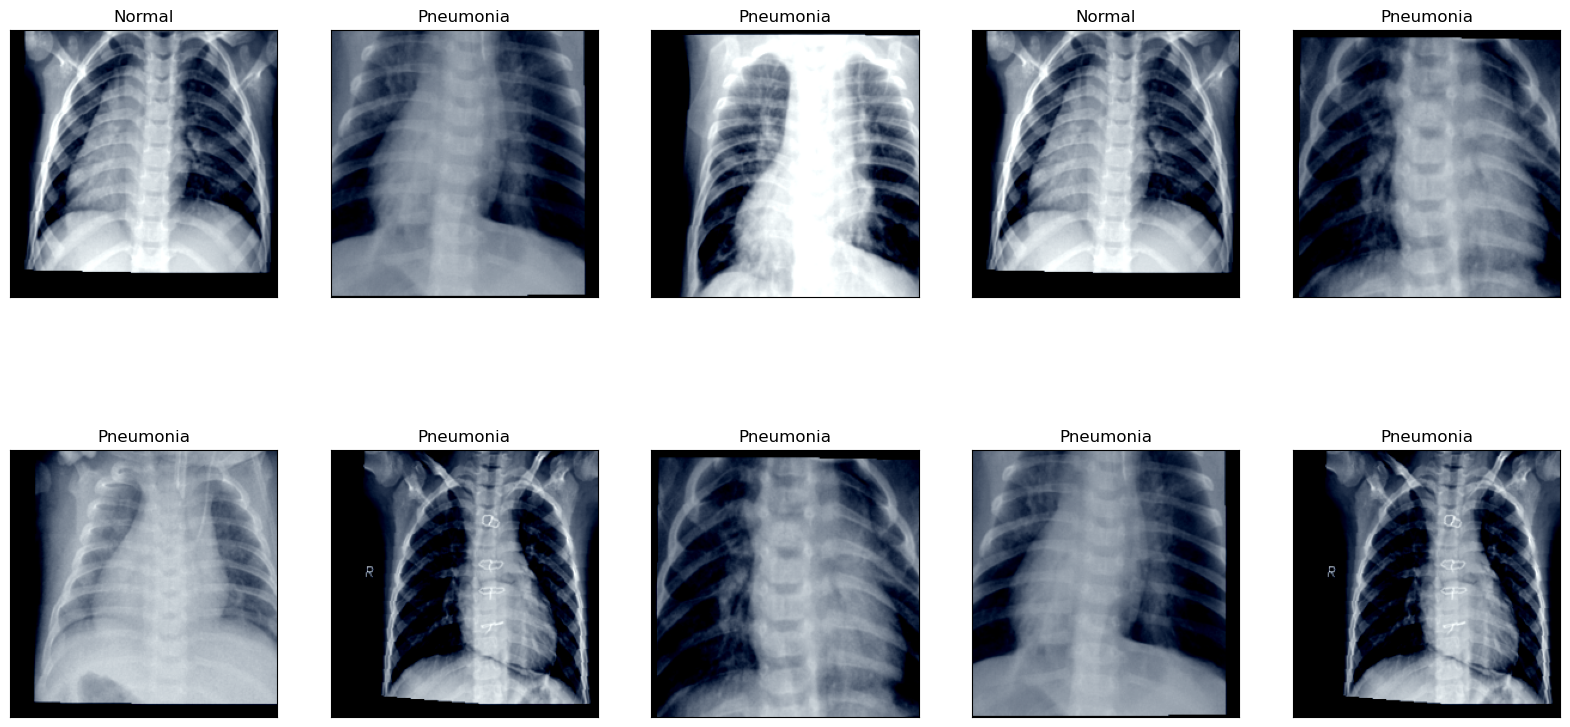

In [9]:
fig = plt.figure(figsize=(20, 10))
for i in range(10):
    idx = np.random.randint(1, len(images))
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    ax.set_title('Normal' if labels[idx].item() == 0 else 'Pneumonia')    
plt.show()
    

In [10]:
# Loading ResNet50 pretrained
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [11]:
# Set requires_grad = False because weights must not change!
for param in model.parameters():
    param.requires_grad = False

# For improving the results we change grad for last layer
for param in model.layer4.parameters():
    param.requires_grad = True

In [12]:
# Get the number of features in the last layer
num_features = model.fc.in_features

# Replace the fully connected layer
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, n_classes)
).to(device)

In [13]:
# Check requires grad for each layer
# for name, param in model.named_parameters():
#     print(name, param.requires_grad)

In [14]:
# Define loss function and optimizer

criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [15]:
def calculate_metrics(val_labels_combined, val_preds_combined, val_probs_combined):
    """Calculates all advanced metrics using Scikit-learn."""
    
    full_metrics = precision_recall_fscore_support(
        val_labels_combined, val_preds_combined, average=None, zero_division=0
    )
    
    precision = full_metrics[0][1] 
    recall = full_metrics[1][1]   
    f1_score = full_metrics[2][1]  
    specificity = full_metrics[1][0] 

    # ROC AUC
    val_auc = roc_auc_score(val_labels_combined, val_probs_combined[:, 1])

    # PR AUC
    precision_points, recall_points, _ = precision_recall_curve(
        val_labels_combined, val_probs_combined[:, 1]
    )
    val_pr_auc = auc(recall_points, precision_points)
    
    return {
        'val_precision': precision,
        'val_recall': recall,
        'val_f1': f1_score,
        'val_auc': val_auc,
        'val_specificity': specificity,
        'val_pr_auc': val_pr_auc
    }

In [16]:
# Training loop

current_datetime = datetime.now().time().strftime("%H:%M:%S")
print(f'Started at: {current_datetime}')

loss_history = []
val_loss_history = []
accuracy_history = []
val_accuracy_history = []

metrics_df = pd.DataFrame(columns=['epoch', 'train_loss', 'train_acc', 
                                   'val_loss', 'val_acc', 'val_precision', 
                                   'val_recall', 'val_f1', 'val_auc', 
                                   'val_specificity', 'val_pr_auc'])

num_epochs = 20
start_epoch = 0
best_val_loss = float('inf')
start = datetime.now()

for epoch in range(start_epoch, num_epochs):

    train_running_loss = 0.0
    val_running_loss = 0.0
    
    train_running_corrects = 0.0
    val_running_corrects = 0.0

    all_val_labels = []
    all_val_preds = []
    all_val_probs = []

    model.train()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass and calculating loss
        outputs = model(images)
        loss = criterion(outputs, labels)
        train_running_loss += loss.item() * images.size(0)

        # Backward pass and updating weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Convert raw logits to probabilties
        _, preds = torch.max(outputs, dim=1)
        train_running_corrects += (preds == labels).sum().item() 

    else:
        with torch.no_grad():

            model.eval()
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # Predicting on val data and calculating the loss
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, dim=1)
                val_running_corrects += (preds == labels).sum().item() 
                probs = torch.softmax(outputs, dim=1)

                all_val_labels.append(labels.cpu().numpy())
                all_val_preds.append(preds.cpu().numpy())
                all_val_probs.append(probs.cpu().numpy())

    val_labels_combined = np.concatenate(all_val_labels)
    val_preds_combined = np.concatenate(all_val_preds)
    val_probs_combined = np.concatenate(all_val_probs)

    precision, recall, f1_score, _ = precision_recall_fscore_support(
        val_labels_combined, val_preds_combined, average='binary', zero_division=0
    )
    val_auc = roc_auc_score(val_labels_combined, val_probs_combined[:, 1])
    

    full_metrics = precision_recall_fscore_support(
        val_labels_combined, val_preds_combined, average=None, zero_division=0
    )
    specificity = full_metrics[1][0]

    precision_points, recall_points, _ = precision_recall_curve(val_labels_combined, val_probs_combined[:, 1])
    val_pr_auc = auc(recall_points, precision_points)
    
    # Get the total samples
    total_train_samples = len(train_loader.dataset)
    total_val_samples = len(val_loader.dataset)
    
    train_acc = train_running_corrects / total_train_samples
    val_acc = val_running_corrects / total_val_samples
    accuracy_history.append(train_acc)
    val_accuracy_history.append(val_acc)

    train_loss = train_running_loss / total_train_samples
    val_loss = val_running_loss / total_val_samples
    loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # Updating learning rate
    scheduler.step(val_loss)

    y_true = val_labels_combined
    y_scores = val_probs_combined[:, 1]

    thresholds_to_test = np.linspace(0.01, 0.99, 100)
    best_threshold = 0.5
    best_specificity = 0
    target_recall = 0.95

    for threshold in thresholds_to_test:
        y_pred = (y_scores >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        current_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        current_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 

        if current_recall >= target_recall and current_specificity > best_specificity:
            best_specificity = current_specificity
            best_threshold = threshold

    print(f"Optimal Threshold found: {best_threshold:.4f} (Specificity at this point: {best_specificity:.4f})")
    
    # Save the best model that has less loss
    if val_loss < best_val_loss:
        print(f"Validation Loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving best model.")
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_weights.pth')

    new_row = {
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_precision': precision,
        'val_recall': recall,       
        'val_f1': f1_score,        
        'val_auc': val_auc,
        'val_specificity': specificity, 
        'val_pr_auc': val_pr_auc
    }

    metrics_df.loc[len(metrics_df)] = new_row

    print(f'\nEpoch {epoch+1}')
    print(f'Train Accuracy: {train_acc * 100:.4f}% ---- Train Loss: {train_loss:.4f}')  
    print(f'Val Accuracy: {val_acc * 100:.4f}% ---- Val Loss: {val_loss:.4f}')  

end = datetime.now()

duration = end - start
print(f"\nIt takes: {duration}")

# Saving the model and sates for running again
CHECKPOINT_PATH = 'checkpoint_last.pth'

state = {
    'epoch': epoch + 1,
    'state_dict': model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'val_loss': val_loss,
    'val_acc': val_acc,
    'optimal_threshold': best_threshold
}

torch.save(state, CHECKPOINT_PATH)
print(f"✅ Checkpoint saved at Epoch {epoch + 1}")

Started at: 17:16:09
Optimal Threshold found: 0.5841 (Specificity at this point: 0.9808)
Validation Loss improved from inf to 0.0880. Saving best model.

Epoch 1
Train Accuracy: 89.3272% ---- Train Loss: 0.2987
Val Accuracy: 97.1154% ---- Val Loss: 0.0880
Optimal Threshold found: 0.7623 (Specificity at this point: 0.9808)
Validation Loss improved from 0.0880 to 0.0858. Saving best model.

Epoch 2
Train Accuracy: 94.7051% ---- Train Loss: 0.1424
Val Accuracy: 96.8750% ---- Val Loss: 0.0858
Optimal Threshold found: 0.6435 (Specificity at this point: 0.9904)
Validation Loss improved from 0.0858 to 0.0710. Saving best model.

Epoch 3
Train Accuracy: 95.7849% ---- Train Loss: 0.1164
Val Accuracy: 97.1154% ---- Val Loss: 0.0710
Optimal Threshold found: 0.3169 (Specificity at this point: 0.9856)

Epoch 4
Train Accuracy: 96.1379% ---- Train Loss: 0.0956
Val Accuracy: 96.6346% ---- Val Loss: 0.0853
Optimal Threshold found: 0.5247 (Specificity at this point: 0.9904)
Validation Loss improved from

In [17]:
metrics_df

,epoch,train_loss,train_acc,val_loss,val_acc,val_precision,val_recall,val_f1,val_auc,val_specificity,val_pr_auc
0,1,0.298719,0.893272,0.088030,0.971154,0.971154,0.971154,0.971154,0.995031,0.971154,0.995558
1,2,0.142395,0.947051,0.085756,0.968750,0.966507,0.971154,0.968825,0.994892,0.966346,0.995034
2,3,0.116360,0.957849,0.070970,0.971154,0.985149,0.956731,0.970732,0.996579,0.985577,0.997309
3,4,0.095629,0.961379,0.085281,0.966346,0.985000,0.947115,0.965686,0.996833,0.985577,0.997025
4,5,0.095005,0.969061,0.068362,0.978365,0.985366,0.971154,0.978208,0.996672,0.985577,0.997089
5,6,0.073586,0.974875,0.096688,0.973558,0.966825,0.980769,0.973747,0.993621,0.966346,0.993350
6,7,0.072293,0.974252,0.061748,0.980769,0.985437,0.975962,0.980676,0.997504,0.985577,0.997759
7,8,0.078002,0.976121,0.083798,0.968750,0.989950,0.947115,0.968059,0.997573,0.990385,0.997839
8,9,0.067410,0.976952,0.065984,0.980769,0.971698,0.990385,0.980952,0.997527,0.971154,0.997916
9,10,0.060289,0.978405,0.158168,0.954327,1.000000,0.908654,0.952141,0.995886,1.000000,0.996446


In [18]:
def load_checkpoint(filepath):
    if not os.path.exists(filepath):
        print(f"Checkpoint file not found at: {filepath}")
        return None, 0

    print(f"Loading checkpoint from: {filepath}...")

    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch']

    print(f"Checkpoint loaded. Continuing from Epoch {start_epoch}.")
    return start_epoch

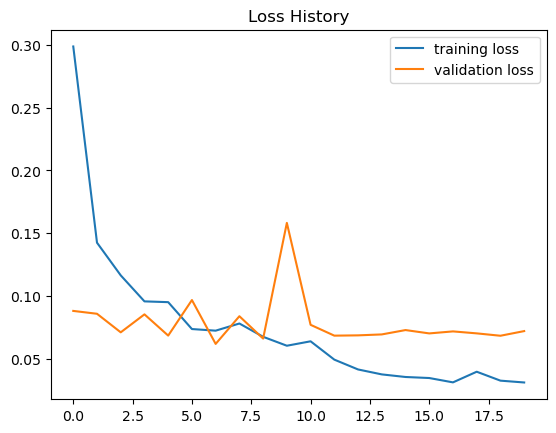

In [19]:
plt.plot(loss_history, label='training loss')
plt.plot(val_loss_history, label='validation loss')
plt.title('Loss History')
plt.legend()
plt.show()

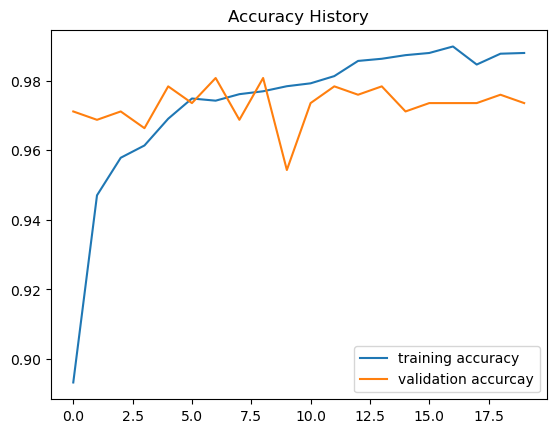

In [20]:
plt.plot(accuracy_history, label='training accuracy')
plt.plot(val_accuracy_history, label='validation accurcay')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [21]:
# Testing the model

test_running_loss = 0.0
test_running_corrects = 0.0

model.eval()

all_test_labels = []
all_test_preds = [] 
all_test_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, dim=1)
        probs = torch.softmax(outputs, dim=1)
        preds_binary = (probs[:, 1] >= best_threshold).int()
        
        test_running_corrects += (preds == labels).sum().item() 

        all_test_labels.append(labels.cpu().numpy())
        all_test_preds.append(preds_binary.cpu().numpy())
        all_test_probs.append(probs.cpu().numpy())

test_labels_combined = np.concatenate(all_test_labels)
test_preds_combined = np.concatenate(all_test_preds)
test_probs_combined = np.concatenate(all_test_probs)

final_test_metrics = calculate_metrics(
    test_labels_combined, 
    test_preds_combined, 
    test_probs_combined
)

total_test_samples = len(test_loader.dataset)

test_loss = test_running_loss / total_test_samples
test_acc = test_running_corrects / total_test_samples

print("\n--- Test Prediction Results ---")
print(f'Test Accuracy: {test_acc * 100:.4f}% ---- Test Loss: {test_loss:.4f}')
print(f"Test Recall at Optimal Threshold ({best_threshold:.4f}): {final_test_metrics['val_recall']:.4f}")
print(f"Test Specificity at Optimal Threshold ({best_threshold:.4f}): {final_test_metrics['val_specificity']:.4f}")


--- Test Prediction Results ---
Test Accuracy: 92.4679% ---- Test Loss: 0.2819
Test Recall at Optimal Threshold (0.7821): 0.9744
Test Specificity at Optimal Threshold (0.7821): 0.8590


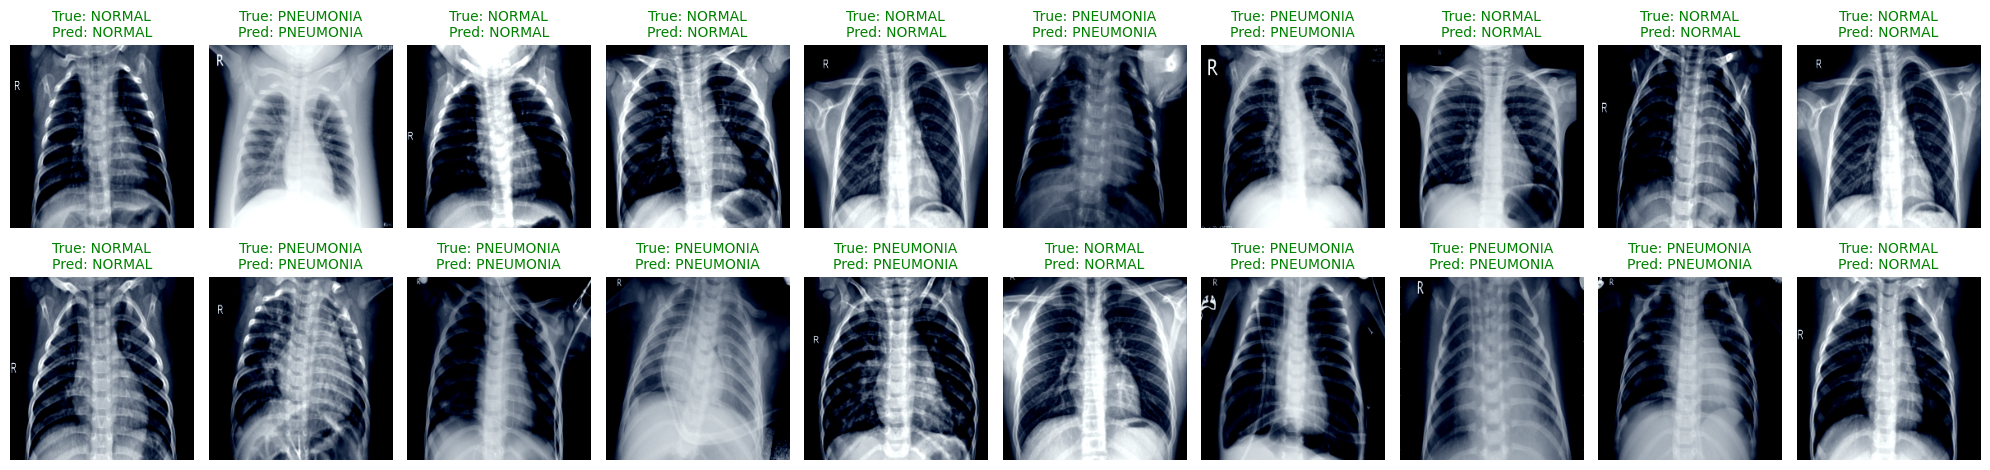

In [25]:
# Get some random images and predict the lables
random_indices = np.random.choice(len(test), size=20)
class_names = test.classes

model.eval()

plt.figure(figsize=(20, 5))

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        images, labels = test[idx]
        images = images.unsqueeze(0).to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        true_labels = class_names[labels]
        pred_labels = class_names[preds.item()]

        is_correct = (true_labels == pred_labels)
        color = "green" if is_correct else "red"

        title = f"True: {true_labels}\nPred: {pred_labels}"

        plt.subplot(2, 10, i+1)
        plt.imshow(im_convert(images))
        plt.title(title, color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout() 
    plt.show()
    

In [45]:
import torch.nn.functional as F
import torch
import numpy as np
import cv2 # برای تغییر اندازه و ترکیب تصاویر
import matplotlib.pyplot as plt

def compute_grad_cam(model, input_tensor, target_layer_name='layer4', target_class=1):
    """
    محاسبه Heatmap Grad-CAM به روش پیاده‌سازی دستی با استفاده از Hookها.
    """
    model.eval()
    
    feature_maps = []
    gradients = []
    
    # 1. تعریف توابع Hook با استفاده از Closure
    def save_feature_maps_local(module, input, output):
        """
        ✅ اصلاح: feature_maps را بدون detach ذخیره می‌کند تا قابلیت ردیابی گرادیان حفظ شود.
        """
        # Feature Map را clone می‌کنیم تا از تغییرات احتمالی in-place در ادامه graph جلوگیری شود.
        # اما detach نمی‌کنیم!
        feature_maps.append(output.clone()) 

    def save_gradients_local(grad):
        """ذخیره گرادیان‌ها در لیست محلی gradients"""
        # ما فقط گرادیان‌های نهایی را ذخیره می‌کنیم
        gradients.append(grad.clone()) 

    # 2. اتصال Hook Forward
    target_layer = dict(model.named_modules())[target_layer_name]
    forward_hook = target_layer.register_forward_hook(save_feature_maps_local)
    
    # --- Forward Pass ---
    # این خط باعث می‌شود تمام خروجی‌ها از این نقطه به بعد، قابلیت ردیابی گرادیان داشته باشند
    input_tensor.requires_grad_(True) 
    outputs = model(input_tensor)
    
    # --- اتصال Hook Backward ---
    if not feature_maps:
         forward_hook.remove()
         raise RuntimeError("Feature maps were not captured. Check target_layer_name.")
         
    # ✅ این خط حالا باید کار کند، چون feature_maps[0] یک تانسور ردیابی شده است.
    backward_hook = feature_maps[0].register_hook(save_gradients_local)
    
    # --- Backward Pass ---
    model.zero_grad()
    target_output = outputs[0, target_class]
    target_output.backward(retain_graph=True) 
    
    # --- جدا کردن Hookها (بسیار حیاتی) ---
    forward_hook.remove()
    backward_hook.remove()

    # --- بررسی و استخراج داده‌ها ---
    if not gradients:
         raise RuntimeError("Gradients were not captured. Check target_class.")

    # استخراج تنسورهای نهایی (برای یک Batch Size = 1) و انتقال به CPU
    fm = feature_maps[0].squeeze(0).cpu() # Feature Maps: [C, H, W]
    grad = gradients[0].squeeze(0).cpu()   # Gradients: [C, H, W]
    
    # --- محاسبه Alpha Weights (اهمیت) ---
    # محاسبه میانگین فضایی گرادیان‌ها (Global Average Pooling) -> [C, 1, 1]
    alpha_weights = grad.mean(dim=[1, 2], keepdim=True) 
    
    # --- تولید Heatmap ---
    # ضرب وزنی: (Alpha * Feature Maps)
    weighted_features = alpha_weights * fm
    
    # مجموع Feature Maps‌های وزن‌دهی شده در کانال‌ها -> [H, W]
    heatmap = weighted_features.sum(dim=0)
    
    # اعمال ReLU و نرمال‌سازی
    heatmap = F.relu(heatmap)
    heatmap /= torch.max(heatmap)
    
    return heatmap.numpy() # تبدیل نهایی به NumPy


# =============================================================================
# --- تابع نمایش (بدون تغییر) ---
# =============================================================================

def show_cam_on_image(img: np.ndarray, mask: np.ndarray, save_path="grad_cam_output.png"):
    """
    پوشش‌دهی Heatmap روی تصویر اصلی.
    
    img: تصویر اصلی (ndarray)
    mask: Heatmap (ndarray)
    """
    # 1. Heatmap را از [0, 1] به طیف رنگی Jet تبدیل می‌کنیم
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    
    # 2. Heatmap را به اندازه تصویر اصلی تغییر اندازه می‌دهیم
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # 3. ترکیب تصویر و Heatmap (با شفافیت)
    img = np.float32(img) / 255
    # تبدیل heatmap به float و نرمال‌سازی بین 0 و 1
    heatmap = np.float32(heatmap) / 255
    
    # ترکیب: 0.4*Heatmap + 0.6*Image
    cam_img = np.uint8(255 * (0.4 * heatmap + 0.6 * img))
    
    # نمایش
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(cam_img, cv2.COLOR_BGR2RGB)) # تبدیل از BGR به RGB برای matplotlib
    plt.axis('off')
    plt.title("Grad-CAM Visualization (PNEUMONIA)")
    plt.savefig(save_path)
    plt.show()
    print(f"✅ Grad-CAM visualization saved as {save_path}")
    
    return cam_img

In [46]:
image_path = "./dataset/test/PNEUMONIA/person1_virus_13.jpeg"
original_image_pil = Image.open(image_path).convert('RGB')

input_tensor = test_transform(original_image_pil).unsqueeze(0).to(device)

np_img = np.array(original_image_pil) 

heatmap_mask = compute_grad_cam(model, input_tensor, 
                               target_layer_name='layer4', 
                               target_class=1)

if heatmap_mask is not None:
    show_cam_on_image(np_img, heatmap_mask)

RuntimeError: Gradients were not captured. Check target_class.